# AQI Prediction - Multi-Model Evaluation & Advanced Feature Engineering

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Settings
import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

# Professional Plot style
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


In [2]:
file_path = r"C:\Users\ACER\Downloads\air+quality (1)\AirQualityUCI.csv"

# Dataset uses ; separator
df = pd.read_csv(file_path, sep=';', decimal=',')

# Drop 'Unnamed' empty columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Drop rows where all elements are NaN
df.dropna(how='all', inplace=True)

print("Dataset Loaded Successfully ✅")
display(df.head())

Dataset Loaded Successfully ✅


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6000,1360.0000,150.0000,11.9000,1046.0000,166.0000,1056.0000,113.0000,1692.0000,1268.0000,13.6000,48.9000,0.7578
1,10/03/2004,19.00.00,2.0000,1292.0000,112.0000,9.4000,955.0000,103.0000,1174.0000,92.0000,1559.0000,972.0000,13.3000,47.7000,0.7255
2,10/03/2004,20.00.00,2.2000,1402.0000,88.0000,9.0000,939.0000,131.0000,1140.0000,114.0000,1555.0000,1074.0000,11.9000,54.0000,0.7502
3,10/03/2004,21.00.00,2.2000,1376.0000,80.0000,9.2000,948.0000,172.0000,1092.0000,122.0000,1584.0000,1203.0000,11.0000,60.0000,0.7867
4,10/03/2004,22.00.00,1.6000,1272.0000,51.0000,6.5000,836.0000,131.0000,1205.0000,116.0000,1490.0000,1110.0000,11.2000,59.6000,0.7888


In [3]:
# Combine Date and Time into a single Datetime column
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H.%M.%S',
    errors='coerce'
)

df = df.drop(['Date', 'Time'], axis=1)

# Replace -200 with NaN (Dataset specific missing value representation)
df.replace(-200, np.nan, inplace=True)

# Ensure Datetime is monotonic and sorted
df = df.sort_values('Datetime').reset_index(drop=True)
df.set_index('Datetime', inplace=True)

print("Missing values per column prior to imputation:")
display(df.isna().sum())

Missing values per column prior to imputation:


CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

In [4]:
# Drop NMHC(GT) because it has around ~90% missing values
if 'NMHC(GT)' in df.columns:
    df.drop('NMHC(GT)', axis=1, inplace=True)

# Fill missing values using time-series specific linear interpolation
df.interpolate(method='linear', limit_direction='both', inplace=True)

print("Missing values after imputation:")
display(df.isna().sum())

Missing values after imputation:


CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

## Exploratory Data Analysis (EDA)

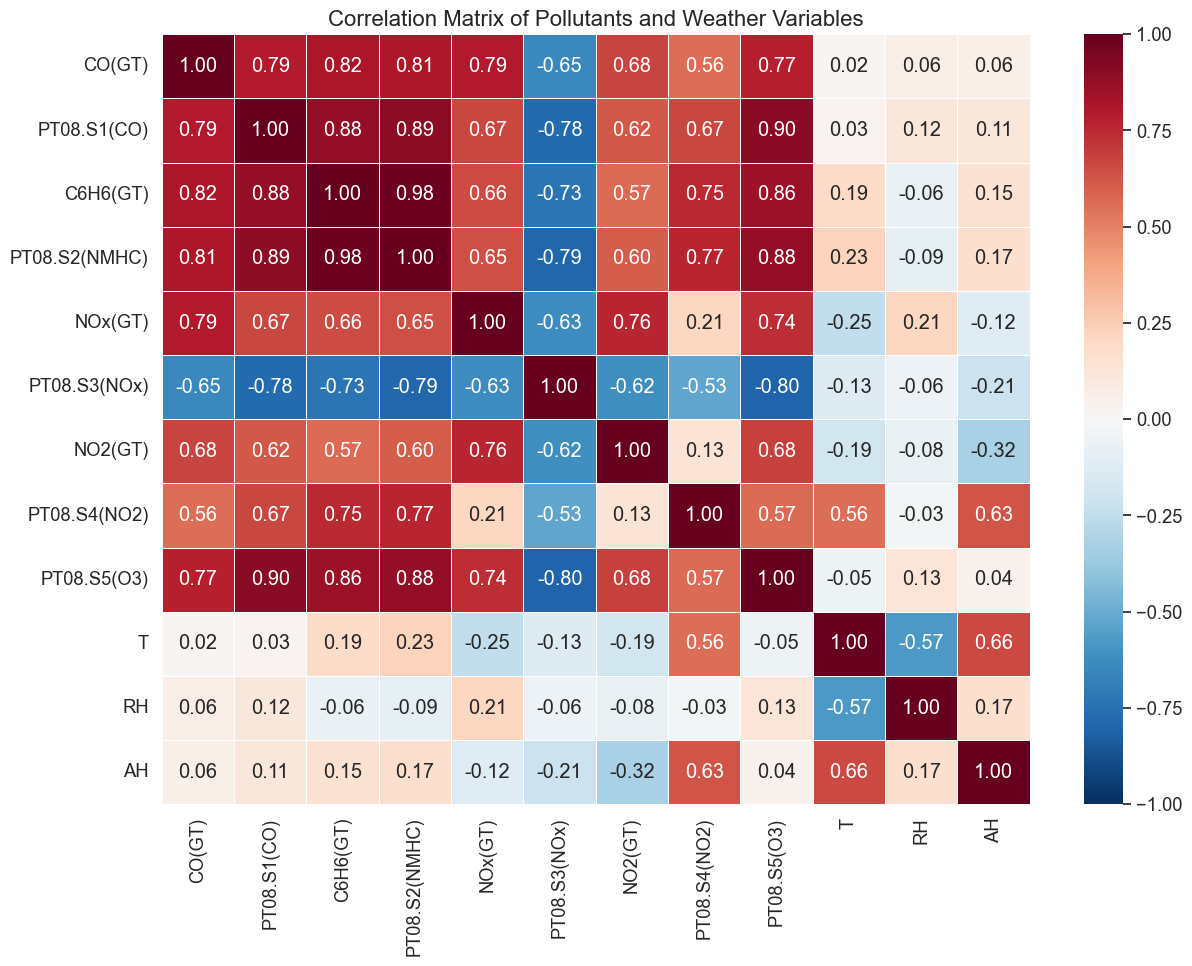

In [5]:
# Correlation Matrix Heatmap
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix of Pollutants and Weather Variables", fontsize=16)
plt.show()

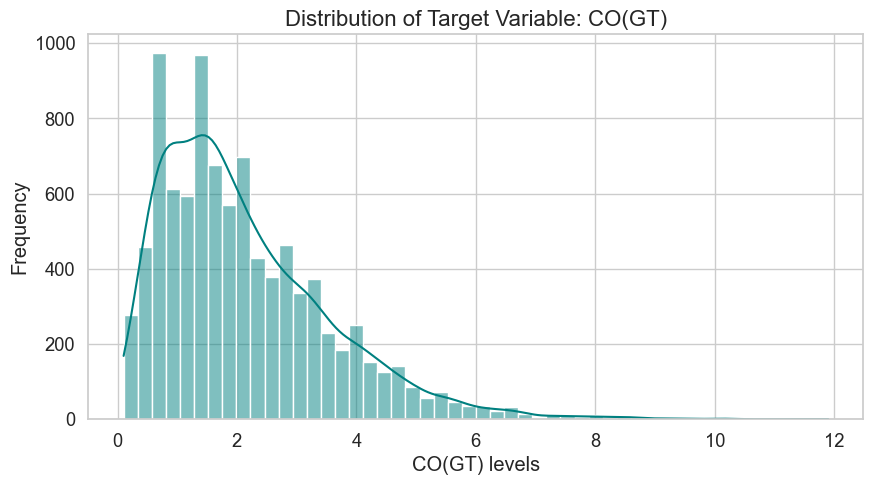

In [6]:
# Target Variable Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['CO(GT)'], bins=50, kde=True, color='teal')
plt.title("Distribution of Target Variable: CO(GT)", fontsize=16)
plt.xlabel("CO(GT) levels")
plt.ylabel("Frequency")
plt.show()

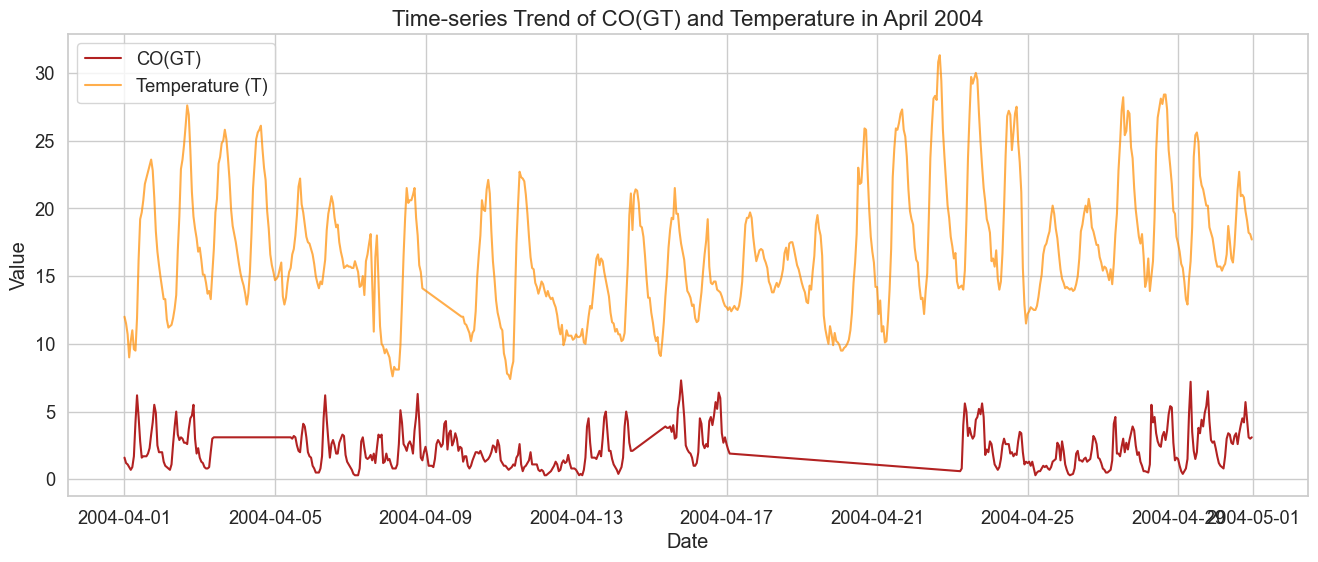

In [7]:
# Time-series trend over a sample month (e.g., April 2004)
sample_df = df.loc['2004-04-01':'2004-04-30']
plt.figure(figsize=(16, 6))
plt.plot(sample_df.index, sample_df['CO(GT)'], label='CO(GT)', color='firebrick')
plt.plot(sample_df.index, sample_df['T'], label='Temperature (T)', color='darkorange', alpha=0.7)
plt.title("Time-series Trend of CO(GT) and Temperature in April 2004", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.show()

## Advanced Feature Engineering

In [ ]:
# 1. Temporal Features
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek
df['Month'] = df.index.month
df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# 2. Cyclical Encoding for Time
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour']/23.0)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour']/23.0)
df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['DayOfWeek']/6.0)
df['DayOfWeek_cos'] = np.cos(2 * np.pi * df['DayOfWeek']/6.0)
df['Month_sin'] = np.sin(2 * np.pi * df['Month']/12.0)
df['Month_cos'] = np.cos(2 * np.pi * df['Month']/12.0)

# 3. Extended Lag Features for multiple key variables
lag_steps = [1, 2, 3, 4, 6]
for lag in lag_steps:
    df[f'CO_lag_{lag}'] = df['CO(GT)'].shift(lag)
    df[f'NOx_lag_{lag}'] = df['NOx(GT)'].shift(lag)
    df[f'NO2_lag_{lag}'] = df['NO2(GT)'].shift(lag)

# 4. Extended Rolling Window Features for recent weather and pollutant trends
windows = [3, 6, 12, 24]
for w in windows:
    df[f'T_roll_{w}'] = df['T'].rolling(window=w).mean()
    df[f'RH_roll_{w}'] = df['RH'].rolling(window=w).mean()
    df[f'AH_roll_{w}'] = df['AH'].rolling(window=w).mean()

pollutant_windows = [3, 6]
for w in pollutant_windows:
    df[f'NOx_roll_{w}'] = df['NOx(GT)'].rolling(window=w).mean()
    df[f'NO2_roll_{w}'] = df['NO2(GT)'].rolling(window=w).mean()

df['T_RH_i# 5. Interaction Terms
nteraction'] = df['T'] * df['RH']

# Drop rows with NaNs generated by shifting and rolling operations
df.dropna(inplace=True)

print(f"Dataset shape after feature engineering: {df.shape}")
display(df.head())

Dataset shape after feature engineering: (9334, 54)


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Hour,DayOfWeek,Month,Is_Weekend,Hour_sin,Hour_cos,DayOfWeek_sin,DayOfWeek_cos,Month_sin,Month_cos,CO_lag_1,NOx_lag_1,NO2_lag_1,CO_lag_2,NOx_lag_2,NO2_lag_2,CO_lag_3,NOx_lag_3,NO2_lag_3,CO_lag_4,NOx_lag_4,NO2_lag_4,CO_lag_6,NOx_lag_6,NO2_lag_6,T_roll_3,RH_roll_3,AH_roll_3,T_roll_6,RH_roll_6,AH_roll_6,T_roll_12,RH_roll_12,AH_roll_12,T_roll_24,RH_roll_24,AH_roll_24,NOx_roll_3,NO2_roll_3,NOx_roll_6,NO2_roll_6,T_RH_interaction
Datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2004-03-11 17:00:00,2.9000,1383.0000,11.2000,1020.0000,243.0000,1008.0000,135.0000,1719.0000,1104.0000,9.8000,67.6000,0.8185,17,3,3,0,-0.9977,-0.0682,0.0000,-1.0000,1.0000,0.0000,2.2000,193.0000,131.0000,2.2000,184.0000,126.0000,2.9000,207.0000,128.0000,1.9000,146.0000,112.0000,1.5000,95.0000,92.0000,9.2667,72.8667,0.8511,8.9333,73.8167,0.8435,9.7417,66.2417,0.7949,10.5500,61.5708,0.7776,206.6667,130.6667,179.5000,121.1667,662.4800
2004-03-11 18:00:00,4.8000,1581.0000,20.8000,1319.0000,281.0000,799.0000,151.0000,2083.0000,1409.0000,10.3000,64.2000,0.8065,18,3,3,0,-0.9791,0.2035,0.0000,-1.0000,1.0000,0.0000,2.9000,243.0000,135.0000,2.2000,193.0000,131.0000,2.2000,184.0000,126.0000,2.9000,207.0000,128.0000,1.6000,104.0000,95.0000,9.9333,67.6667,0.8273,9.0667,73.3833,0.8454,9.7250,66.7500,0.8008,10.4125,62.2083,0.7796,239.0000,139.0000,209.0000,130.5000,661.2600
2004-03-11 19:00:00,6.9000,1776.0000,27.4000,1488.0000,383.0000,702.0000,172.0000,2333.0000,1704.0000,9.7000,69.3000,0.8319,19,3,3,0,-0.8879,0.4601,0.0000,-1.0000,1.0000,0.0000,4.8000,281.0000,151.0000,2.9000,243.0000,135.0000,2.2000,193.0000,131.0000,2.2000,184.0000,126.0000,1.9000,146.0000,112.0000,9.9333,67.0333,0.8190,9.3000,72.2000,0.8442,9.6833,67.5583,0.8083,10.2625,63.1083,0.7841,302.3333,152.6667,248.5000,140.5000,672.2100
2004-03-11 20:00:00,6.1000,1640.0000,24.0000,1404.0000,351.0000,743.0000,165.0000,2191.0000,1654.0000,9.6000,67.8000,0.8133,20,3,3,0,-0.7308,0.6826,0.0000,-1.0000,1.0000,0.0000,6.9000,383.0000,172.0000,4.8000,281.0000,151.0000,2.9000,243.0000,135.0000,2.2000,193.0000,131.0000,2.9000,207.0000,128.0000,9.8667,67.1000,0.8172,9.5667,69.9833,0.8342,9.5833,68.4250,0.8144,10.1667,63.6833,0.7867,338.3333,162.6667,272.5000,146.6667,650.8800
2004-03-11 21:00:00,3.9000,1313.0000,12.8000,1076.0000,240.0000,957.0000,136.0000,1707.0000,1285.0000,9.1000,64.0000,0.7419,21,3,3,0,-0.5196,0.8544,0.0000,-1.0000,1.0000,0.0000,6.1000,351.0000,165.0000,6.9000,383.0000,172.0000,4.8000,281.0000,151.0000,2.9000,243.0000,135.0000,2.2000,184.0000,126.0000,9.4667,67.0333,0.7957,9.7000,67.3500,0.8115,9.4667,68.7083,0.8121,10.0875,63.8500,0.7848,324.6667,157.6667,281.8333,148.3333,582.4000


## Model Training and Evaluation Pipeline

In [9]:
# Define features (X) and target (y)
X = df.drop('CO(GT)', axis=1)
y = df['CO(GT)']

# Train-Test Split (Since it's time series, we split sequentially to avoid data leakage)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Testing shapes: X={X_test.shape}, y={y_test.shape}")

Training shapes: X=(7467, 53), y=(7467,)
Testing shapes: X=(1867, 53), y=(1867,)


In [10]:
# Initialize Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    
    # Predict
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    results.append({
        "Model": name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Test RMSE": test_rmse
    })

results_df = pd.DataFrame(results)
display(results_df)

Training Linear Regression...
Training Random Forest...
Training Gradient Boosting...
Training XGBoost...


,Model,Train R2,Test R2,Test RMSE
0,Linear Regression,0.9393,0.9356,0.3508
1,Random Forest,0.9932,0.9027,0.4311
2,Gradient Boosting,0.9559,0.9095,0.4159
3,XGBoost,0.9967,0.9108,0.4129


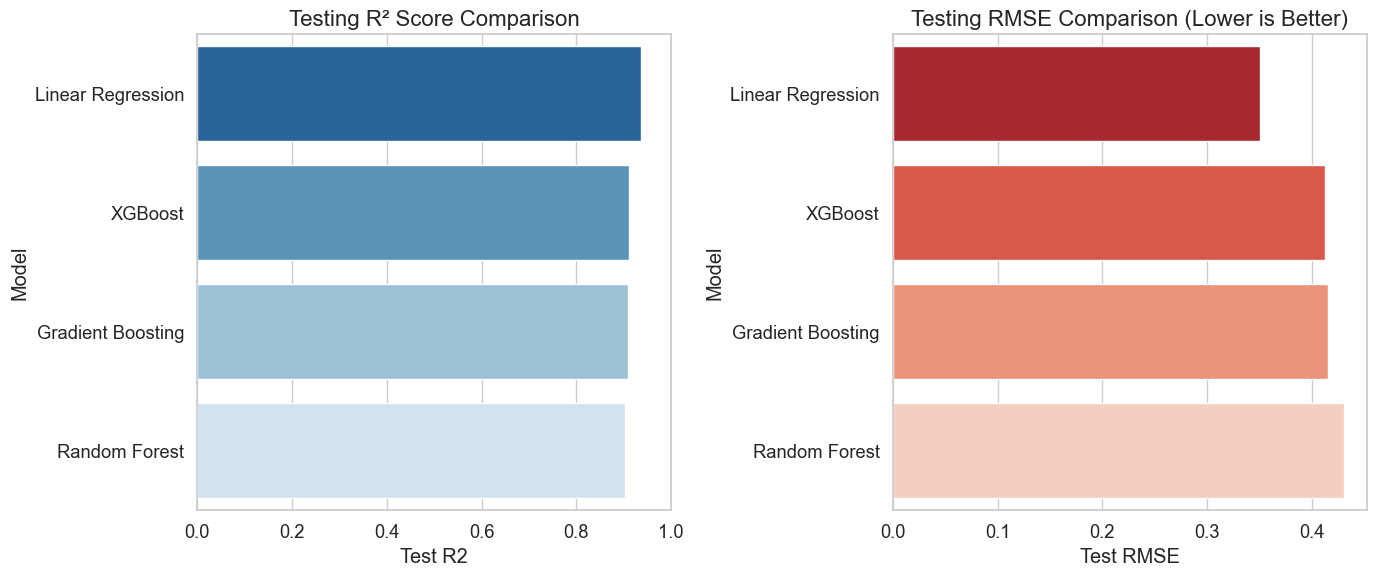

In [ ]:
# Visualizing Model Performances
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Test R2', y='Model', data=results_df.sort_values('Test R2', ascending=False), palette='Blues_r')
plt.title('Testing R² Score Comparison', fontsize=16)
plt.xlim(0, 1)

plt.subplot(1, 2, 2)
sns.barplot(x='Test RMSE', y='Model', data=results_df.sort_values('Test RMSE', ascending=True), palette='Reds_r')
plt.title('Testing RMSE Comparison (Lower is Better)', fontsize=16)

plt.tight_layout()
plt.show()

In [12]:
# Plot Feature Importances (From the best model - XGBoost or Random Forest)
best_model_name = results_df.sort_values('Test R2', ascending=False).iloc[0]['Model']
best_model = models[best_model_name]

# If the best model is tree-based and has feature importances
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(12, 12))
    sns.barplot(x='Importance', y='Feature', data=feat_df.head(25), palette='viridis')
    plt.title(f"Top 25 Feature Importances in {best_model_name} Model", fontsize=16)
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.show()
else:
    print(f"Best model '{best_model_name}' does not have feature_importances_ attribute.")

Best model 'Linear Regression' does not have feature_importances_ attribute.
